<a id="top"></a>
# Chapter 3 — Three dimensions, Wannier90 import and Wannierization

**PythTB — Tight-Binding Physics from Theory to Code** · Part I — Fundamentals · chapter 3 of 8

[◀ 2 Finite systems, spin and the Berry-phase machinery](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [Contents of the book](README.md) · [4 Chern and Z₂ insulators: Haldane, Kane–Mele, BHZ ▶](PythTB_04_Chern_and_Z2.ipynb)

**In this chapter**

- [§11 Three dimensions](#sec-11)
- [§12 Real materials — importing Wannier90 models (`W90`)](#sec-12)
- [§13 Wannierization *inside* PythTB — the `Wannier` class](#sec-13)
- [Exercises for Part I](#exercises-I)

All chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb) · exercises: [Parts I–II](PythTB_Exercises_I-II.ipynb) · [Parts III–IV](PythTB_Exercises_III-IV.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# the Wannier90 silicon data (§12) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 27}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__, "| chapter 3")
t_chapter_start = time.time()

pythtb 2.0.0 | numpy 2.5.2 | chapter 3


In [2]:
# recap — rebuilt from §6 (chapter 2) so that this chapter runs on its own
def ssh_model(v, w):
    lat = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.5]], periodic_dirs=[0])
    m = TBModel(lat)
    m.set_hop(v, 0, 1, [0])
    m.set_hop(w, 1, 0, [1])
    return m

<a id="sec-11"></a>

## 11. Three dimensions

Nothing changes structurally in 3D — `Lattice` takes three vectors, k-points get three reduced
components, `cut_piece` turns a bulk crystal into a slab — but it is worth pausing on what *scales*:
a k-mesh now has $N^3$ points, and every Berry-flux or Chern calculation multiplies accordingly.
PythTB stays comfortable because tight-binding matrices stay small; the cost lives entirely in the
number of k-points (Part III measures it).

Below: the simple-cubic band $E(\mathbf k) = -2t(\cos K_x + \cos K_y + \cos K_z)$ checked against
the code, and its density of states with the van Hove singularities of a 3D cosine band. (For
interactive 3D structure views, `TBModel.visualize_3d()` renders the lattice with plotly if
installed; we stay with matplotlib here.)

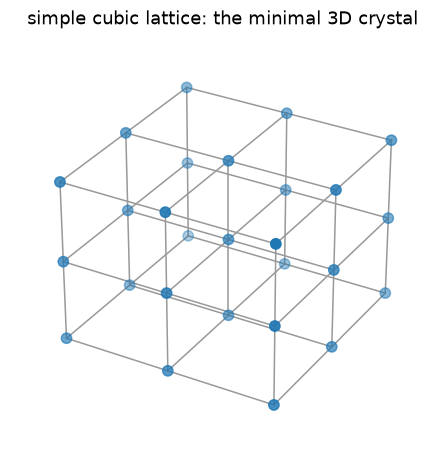

In [3]:
# the crystal itself: simple cubic, one orbital per site, six equal NN bonds
fig = plt.figure(figsize=(5.5, 5))
ax = fig.add_subplot(projection="3d")
pts = np.array([[i, j, k] for i in range(3) for j in range(3) for k in range(3)])
for p in pts:
    for d in np.eye(3, dtype=int):
        q = p + d
        if q.max() < 3:
            ax.plot(*zip(p, q), "-", color="0.6", lw=1)
ax.scatter(*pts.T, s=45, c="C0", depthshade=True)
ax.set_axis_off()
ax.set_title("simple cubic lattice: the minimal 3D crystal")
plt.show()
caption("The simple cubic lattice: one orbital per site, hopping −t along each of "
        "the three axes. Its band is the sum of three independent 1D cosine bands — "
        "the rare 3D problem with a closed-form answer, which is why it opens the "
        "3D part of this notebook as the analytic benchmark.")

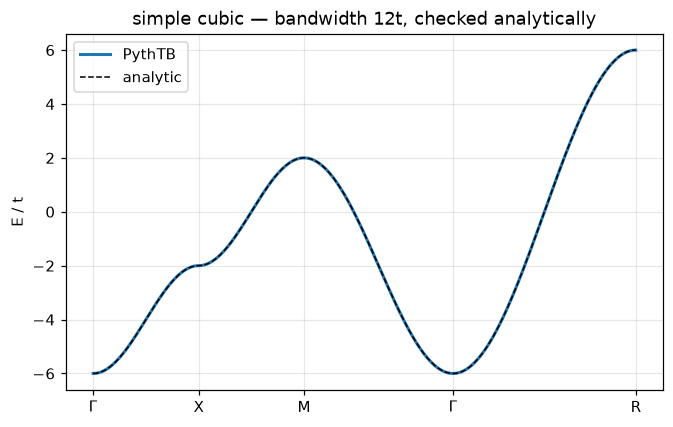

[PASS] simple-cubic band matches -2t Σ cos


True

In [4]:
# simple cubic crystal, one orbital
t = 1.0
lat_sc = Lattice(lat_vecs=np.eye(3), orb_vecs=[[0, 0, 0]], periodic_dirs=[0, 1, 2])
cubic = TBModel(lat_sc)
for d in range(3):
    R = [0, 0, 0]; R[d] = 1
    cubic.set_hop(-t, 0, 0, R)

CUBIC_NODES = [[0, 0, 0], [0.5, 0, 0], [0.5, 0.5, 0], [0, 0, 0], [0.5, 0.5, 0.5]]
CUBIC_LABELS = [r"$\Gamma$", "X", "M", r"$\Gamma$", "R"]
k_vec, k_dist, k_node = cubic.k_path(CUBIC_NODES, nk=301, report=False)
ev = cubic.solve_ham(k_vec)

E_exact = -2 * t * np.cos(2 * np.pi * k_vec).sum(axis=1)
fig, ax = plt.subplots()
ax.plot(k_dist, ev[:, 0], lw=2, label="PythTB")
ax.plot(k_dist, E_exact, "k--", lw=1, label="analytic")
ax.set_xticks(k_node, CUBIC_LABELS)
ax.set_ylabel("E / t")
ax.legend(); ax.set_title("simple cubic — bandwidth 12t, checked analytically")
plt.show()
caption("The simple-cubic band along a standard path. Reading it dimension by "
        "dimension: bandwidth 12t = 3 × 4t (one 4t per axis), minimum at Γ where "
        "all three cosines add, maximum at the zone corner R where all three "
        "subtract. Numerics and the analytic sum of cosines are indistinguishable.")

check("simple-cubic band matches -2t Σ cos", np.allclose(ev[:, 0], E_exact, atol=1e-12))

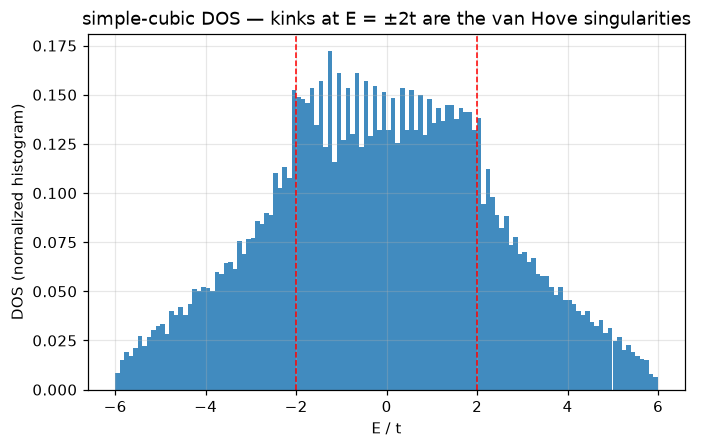

diagonalized 216,000 k-points in one vectorized call


In [5]:
# density of states on a full 3D mesh: van Hove singularities of the cosine band
k_mesh = cubic.k_uniform_mesh([60, 60, 60])
ev_mesh = cubic.solve_ham(k_mesh).ravel()

fig, ax = plt.subplots()
ax.hist(ev_mesh, bins=120, density=True, color="C0", alpha=0.85)
for E_vh in (-2 * t, 2 * t):
    ax.axvline(E_vh, color="r", ls="--", lw=1)
ax.set_xlabel("E / t")
ax.set_ylabel("DOS (normalized histogram)")
ax.set_title("simple-cubic DOS — kinks at E = ±2t are the van Hove singularities")
plt.show()
caption("Density of states from a histogram of 216,000 eigenvalues. In 3D the "
        "van Hove singularities are kinks (discontinuous slope) rather than the "
        "divergences of 2D — the dimensionality of a material is legible in the "
        "SHAPE of its DOS anomalies. The band edges at ±6t rise as √|E − E_edge|, "
        "the free-electron-like signature of a parabolic band minimum.")
print(f"diagonalized {len(ev_mesh):,} k-points in one vectorized call")

<a id="sec-12"></a>

## 12. Real materials — importing Wannier90 models (`W90`)

Everything so far used hand-picked hoppings. The `W90` class is PythTB's bridge to *ab-initio*
reality: it reads the output of a [Wannier90](http://wannier.org) run (`prefix_hr.dat`,
`prefix.win`, `prefix_centres.xyz`, …) — i.e. a DFT band structure compressed into
maximally-localized Wannier functions — and returns an ordinary `TBModel`. Every tool in this
notebook then applies unchanged to a first-principles Hamiltonian.

The dataset in `data/w90_silicon/` (from the PythTB distribution) is **bulk silicon** with 8
Wannier functions (bonding + antibonding sp³ combinations) on a $10\times10\times10$ k-grid, in eV
and Å. Things to inspect before trusting an imported model:

1. **hopping decay** — `dist_hop()` shows $|t(r)|$ falling exponentially with distance; a slow decay
   means poorly localized Wannier functions and an untrustworthy truncation;
2. **truncation error** — `model(min_hopping_norm=…)` drops small hoppings; compare interpolated
   bands against the original Wannier90 bands (`bands_w90()`) to see what the cut costs;
3. the **Fermi level** — Wannier90 files carry absolute DFT energies; `zero_energy` re-references
   them.

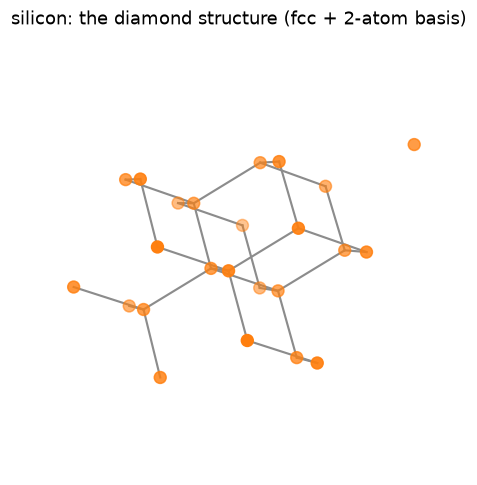

In [6]:
# the material: silicon crystallizes in the diamond structure — an fcc lattice
# with a two-atom basis, every atom tetrahedrally bonded to four neighbours
a1 = np.array([0.0, 0.5, 0.5]); a2 = np.array([0.5, 0.0, 0.5]); a3 = np.array([0.5, 0.5, 0.0])
basis = [np.zeros(3), 0.25 * (a1 + a2 + a3)]            # (0,0,0) and (1/4,1/4,1/4)
atoms = []
for i in range(-1, 2):
    for j in range(-1, 2):
        for k in range(-1, 2):
            R = i * a1 + j * a2 + k * a3
            for b in basis:
                atoms.append(R + b)
atoms = np.array(atoms)
keep = np.all((atoms > -0.3) & (atoms < 1.1), axis=1)
atoms = atoms[keep]

fig = plt.figure(figsize=(5.8, 5.2))
ax = fig.add_subplot(projection="3d")
d2a = np.sum((atoms[:, None, :] - atoms[None, :, :]) ** 2, axis=-1)
for i, j in zip(*np.where(np.abs(np.sqrt(d2a) - np.sqrt(3) / 4) < 1e-6)):
    if i < j:
        ax.plot(*zip(atoms[i], atoms[j]), "-", color="0.55", lw=1.4)
ax.scatter(*atoms.T, s=60, c="C1", depthshade=True)
ax.set_axis_off()
ax.set_title("silicon: the diamond structure (fcc + 2-atom basis)")
plt.show()
caption("The diamond structure of silicon: two interpenetrating fcc lattices, each "
        "atom bonded tetrahedrally to four neighbours. Four sp³ bonding orbitals per "
        "atom pair fill to make the valence bands; the Wannier90 dataset below "
        "compresses exactly those bands (plus four antibonding partners) into 8 "
        "localized functions whose hoppings PythTB reads back in.")

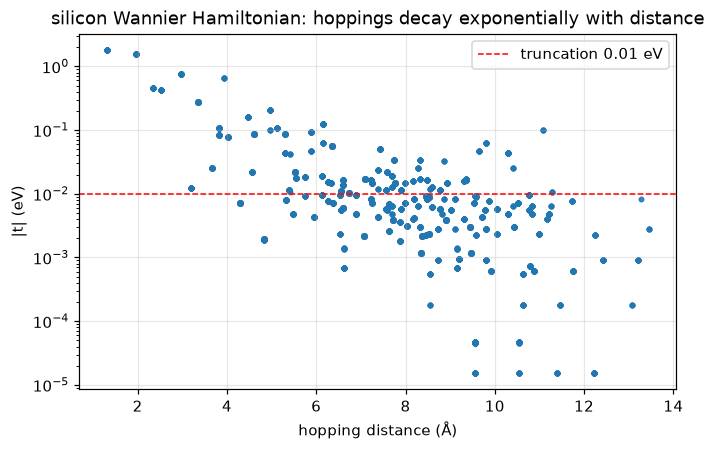

In [7]:
silicon = W90(os.path.join(DATA_DIR, "w90_silicon"), "si")
fermi_ev = 6.2285135          # DFT Fermi level of this calculation, in eV

dist, ham = silicon.dist_hop()
fig, ax = plt.subplots()
ax.scatter(dist, np.abs(ham), s=8, alpha=0.6)
ax.axhline(1e-2, color="r", ls="--", lw=1, label="truncation 0.01 eV")
ax.set_yscale("log")
ax.set_xlabel("hopping distance (Å)")
ax.set_ylabel("|t| (eV)")
ax.legend()
ax.set_title("silicon Wannier Hamiltonian: hoppings decay exponentially with distance")
plt.show()
caption("Every hopping matrix element of the silicon Wannier Hamiltonian versus "
        "bond length, on a log scale: five orders of magnitude of clean exponential "
        "decay. This is the numerical face of Kohn's 'nearsightedness' — gapped "
        "bands have exponentially localized Wannier functions — and it is what "
        "makes the truncation studied next a controlled approximation rather than "
        "a leap of faith.")

[PASS] untruncated import reproduces Wannier90 bands exactly — max deviation = 0.0145 meV


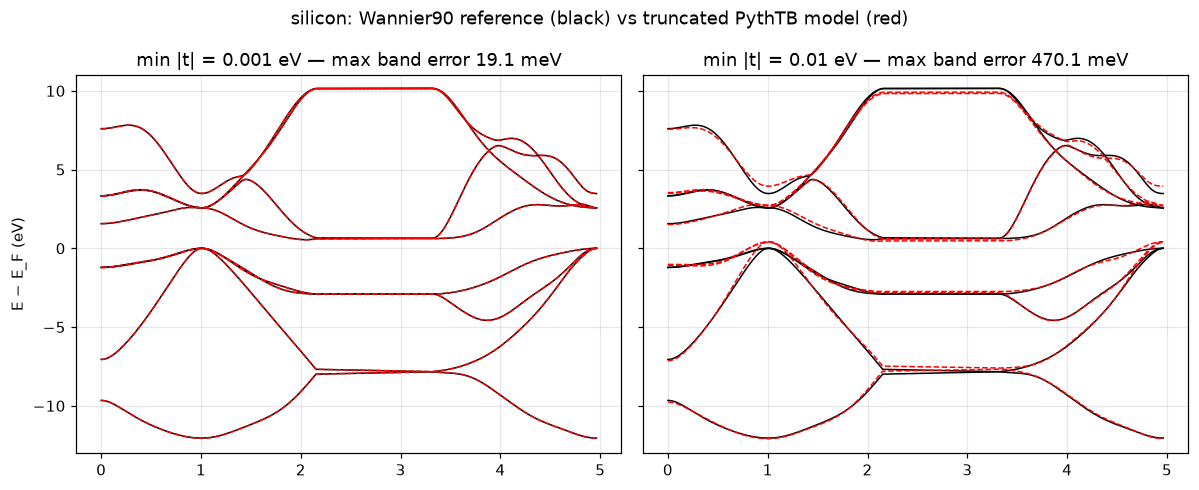

[PASS] 1 meV truncation keeps bands within ~20 meV — max error = 19.1 meV
[PASS] 10x coarser truncation degrades bands ~20x — 470 meV vs 19.1 meV


True

In [8]:
# import at two truncation levels and compare against the Wannier90 reference bands
w90_kpt, w90_evals, w90_k_dist, w90_k_nodes, w90_k_labels = silicon.bands_w90(
    return_k_dist=True, return_k_nodes=True)

# untruncated import first: at Wannier90's own k-points the model must be EXACT
model_full = silicon.model(zero_energy=fermi_ev)
err_full = np.abs(model_full.solve_ham(w90_kpt) - (w90_evals - fermi_ev)).max()
check("untruncated import reproduces Wannier90 bands exactly", err_full < 1e-4,
      f"max deviation = {1000*err_full:.4f} meV")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
errors = {}
for ax, cut in zip(axs, (1e-3, 1e-2)):
    model_si = silicon.model(zero_energy=fermi_ev, min_hopping_norm=cut)
    int_evals = model_si.solve_ham(w90_kpt)
    err = np.abs(int_evals - (w90_evals - fermi_ev)).max()
    errors[cut] = err
    ax.plot(w90_k_dist, w90_evals - fermi_ev, "k-", lw=1)
    ax.plot(w90_k_dist, int_evals, "r--", lw=1)
    ax.set_title(f"min |t| = {cut} eV — max band error {1000*err:.1f} meV")
    ax.set_ylim(-13, 11)
axs[0].set_ylabel("E − E_F (eV)")
fig.suptitle("silicon: Wannier90 reference (black) vs truncated PythTB model (red)")
fig.tight_layout()
plt.show()
caption("First-principles silicon bands (black) against the truncated tight-binding "
        "model (red dashed) at two truncation levels. Keeping hoppings down to 1 meV "
        "reproduces DFT to ~20 meV across 8 bands and 17 eV of bandwidth — from a "
        "Hamiltonian with a few hundred numbers. The right panel shows the price of "
        "an aggressive cut: the conduction bands, whose Wannier functions spread "
        "further, degrade first (quantified in exercise I.6).")

check("1 meV truncation keeps bands within ~20 meV", errors[1e-3] < 0.05,
      f"max error = {1000*errors[1e-3]:.1f} meV")
check("10x coarser truncation degrades bands ~20x", errors[1e-2] > 5 * errors[1e-3],
      f"{1000*errors[1e-2]:.0f} meV vs {1000*errors[1e-3]:.1f} meV")

In [9]:
# a first-principles model is a TBModel like any other: Berry machinery applies as-is.
# Berry phase of the 4 valence bands along k_z at (kx,ky)=(0,0) — quantized to 0 or π
# by the inversion symmetry of the diamond structure.
model_si = silicon.model(zero_energy=fermi_ev, min_hopping_norm=1e-2)

mesh = Mesh(["k", "k", "k"])
mesh.build_grid([6, 6, 31], k_endpoints=[False, False, True])
wfa_si = WFArray(model_si.lattice, mesh)
wfa_si.solve_model(model_si)
phi_z = wfa_si.berry_phase(axis_idx=2, state_idx=[0, 1, 2, 3])   # over (kx,ky) grid
phi_00 = float(np.atleast_2d(np.squeeze(phi_z))[0, 0])
print(f"valence-band Berry phase along k_z at k_perp=0: φ = {phi_00:+.6f}")
dist_to_quant = min(abs(phi_00 % np.pi), np.pi - abs(phi_00 % np.pi))
check("silicon valence Berry phase quantized by inversion symmetry",
      dist_to_quant < 1e-3, f"distance from multiple of π: {dist_to_quant:.2e}")

valence-band Berry phase along k_z at k_perp=0: φ = -0.000089
[PASS] silicon valence Berry phase quantized by inversion symmetry — distance from multiple of π: 8.94e-05


True

<a id="sec-13"></a>

## 13. Wannierization *inside* PythTB — the `Wannier` class

PythTB 2.0 closes a loop that used to require Wannier90 itself: starting from Bloch states in a
`WFArray`, the `Wannier` class **projects onto trial orbitals, disentangles, and maximally
localizes** Wannier functions — the Marzari–Vanderbilt $\Omega$ minimization — entirely in Python.

We test it where the answer is known exactly (§9): the trivial-phase SSH occupied band has its
Wannier center on the intracell bond, $\bar x = 0.25$, and the Wannier function must decay
exponentially. The workflow: `project(tf_list, band_idxs)` → `maxloc()` → inspect `spread`,
`centers`, real-space decay.

In [10]:
# Wannierize the occupied band of the trivial SSH chain
m = ssh_model(1.0, 0.5)
mesh = Mesh(["k"])
mesh.build_grid([60])                      # full BZ grid, no duplicate endpoint
wfa = WFArray(m.lattice, mesh)
wfa.solve_model(m)

WF = Wannier(wfa)
WF.project([[(0, 1)]], band_idxs=[0])      # trial wf: orbital 0 of the cell
print("after projection:")
WF.info()
WF.maxloc(max_iter=2000, tol=1e-12, grad_min=1e-12, verbose=False)
print("\nafter maximal localization:")
WF.info()

centers = np.atleast_2d(WF.centers)
xbar_wf = float(centers[0, 0]) % 1.0
print(f"\nWannier center from localization: {xbar_wf:.6f}  (Berry phase in §9 gave 0.250000)")
check("maxloc Wannier center agrees with the Berry phase",
      np.isclose(xbar_wf, 0.25, atol=1e-3), f"x̄ = {xbar_wf:.6f}")

after projection:
Wannier Function Report
WF 1: center = [0.25000000]  Omega     = 0.14553548
Sum : center = [0.25000000]  Omega tot = 0.14553548
---------------------------------------------------
Omega I   = 0.10395324
Omega D   = 0.04158225
Omega OD  = 0.00000000
Omega tot = 0.14553548



after maximal localization:
Wannier Function Report
WF 1: center = [0.25000000]  Omega     = 0.10395377
Sum : center = [0.25000000]  Omega tot = 0.10395377
---------------------------------------------------
Omega I   = 0.10395324
Omega D   = 0.00000054
Omega OD  = 0.00000000
Omega tot = 0.10395377

Wannier center from localization: 0.250000  (Berry phase in §9 gave 0.250000)
[PASS] maxloc Wannier center agrees with the Berry phase — x̄ = 0.250000


True

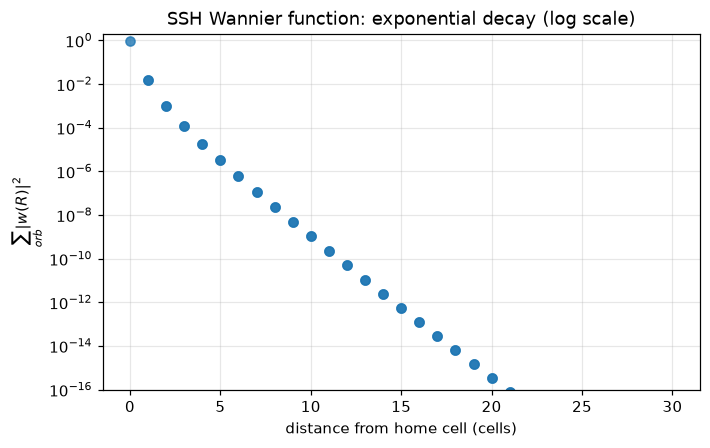

[PASS] Wannier function decays exponentially — decay rate = -1.86 per cell


True

In [11]:
# real-space profile of the Wannier function. WF.wannier holds the amplitudes with
# shape (n_cells, n_wf, n_orb); the built-in WF.plot_decay assumes >= 2D lattices,
# so for this 1D chain we plot the decay ourselves.
w_amp = np.asarray(WF.wannier)[:, 0, :]            # (n_cells, n_orb)
n_cells = w_amp.shape[0]
cell_dist = np.minimum(np.arange(n_cells), n_cells - np.arange(n_cells))  # wrap
dens_cell = (np.abs(w_amp) ** 2).sum(axis=1)

fig, ax = plt.subplots()
ax.semilogy(cell_dist, dens_cell, "o", alpha=0.8)
ax.set_xlabel("distance from home cell (cells)")
ax.set_ylabel(r"$\sum_{orb} |w(R)|^2$")
ax.set_ylim(1e-16, 2)
ax.set_title("SSH Wannier function: exponential decay (log scale)")
plt.show()
caption("Real-space profile of the maximally-localized Wannier function built by "
        "PythTB's own Wannier engine from the SSH Bloch states: exponential decay "
        "over ten orders of magnitude, centred on the strong bond. The decay rate is "
        "set by the gap — shrink the gap and the Wannier function fattens, which is "
        "the localization-topology trade-off behind everything in Part II.")

# a gapped 1D insulator must have exponentially localized Wannier functions:
# fit log-density vs distance over the first decade and require a negative slope
mask = (cell_dist >= 1) & (cell_dist <= 8) & (dens_cell > 1e-14)
slope = np.polyfit(cell_dist[mask], np.log(dens_cell[mask]), 1)[0]
check("Wannier function decays exponentially", slope < -1.0,
      f"decay rate = {slope:.2f} per cell")

<a id="exercises-I"></a>

## Exercises for Part I

Worked solutions are in [`PythTB_Exercises_I-II.ipynb`](PythTB_Exercises_I-II.ipynb) (this folder).

**I.1 — The trestle.** Build the classic PythTB "trestle" model: a 1D chain with two orbitals per
cell at heights 0 and 0.5 in a non-periodic second direction, first-neighbour hopping $t$ along the
chain and diagonal hoppings $t'$ between the rails. Plot the two bands and find the $t'/t$ ratio at
which the gap at the zone boundary closes.

**I.2 — Breaking particle–hole symmetry.** Add a second-neighbour hopping $t' = 0.1t$ to graphene
(six bonds per sublattice). Show that the Dirac points survive but move away from $E = 0$, and
compute the new energy of the band touching. Why does the *existence* of the touching not care
about $t'$?

**I.3 — (Non-)fragility of flat bands.** Perturb the Lieb lattice two ways: (a) a direct
corner–corner hopping $t_2$ across the square, (b) a diagonal edge–edge hopping $t_2$. One of them
leaves the flat band *exactly* flat and the other disperses it — predict which before computing,
explain why in terms of where the flat-band states live, and find the $t_2/t$ at which the
dispersing case reaches a bandwidth of 10% of the main gap.

**I.4 — Polarization of BN.** For the boron-nitride model at fixed $|Δ|$, compute the Berry phase
of the valence band along $k_1$ as a function of $k_2$ for both signs of $Δ$. The polarization
jump is quantized — but is it $e/2$, as a naive "half a quantum per band inversion" guess would
say? Determine the exact fraction and connect it to the $C_3$-pinned Wyckoff positions of the
valence Wannier center on the honeycomb.

**I.5 — A pump that pumps nothing.** Modify the Rice–Mele cycle so the $(v-w, \Delta)$ loop does
*not* enclose the origin (e.g. $\Delta(\lambda) = \Delta_0[1.5 + \sin 2\pi\lambda]$). Show the
Wannier-center flow now winds zero times and the $(k,\lambda)$ Chern number vanishes.

**I.6 — Silicon conduction bands.** The 8-band silicon model of §12 also contains 4 antibonding
bands. Quantify how much worse the Wannier interpolation is for the conduction bands than for the
valence bands (compare against `bands_w90()`), and explain why in terms of the disentanglement
window used to generate the data.

In [12]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 3 — checks passed : {_CHECKS['pass']}")
print(f"chapter 3 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 3 — checks passed : 7
chapter 3 — checks failed : 0
wall time                 : 3 s
Every quantitative claim in this notebook was verified in this run.
